# Swan Teleco — Customer Retention Analysis

# 1. Setup

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score
from sklearn import metrics

DATA_PATH = "1 - Project Data.csv"

NAVY = "#163E67"
MID = "#6A96C2"
PALE = "#C9DCEF"
RED = "#C1121F"

BINARY = [MID, NAVY]
BLUES = sns.light_palette(NAVY, as_cmap=True)

def blue_ramp(n, reverse=False):
    ends = [PALE, NAVY] if reverse else [NAVY, PALE]
    return sns.blend_palette(ends, n_colors=n)

ADDONS = ["Online Security", "Online Backup", "Device Protection",
          "Tech Support", "Streaming TV", "Streaming Movies"]
NUMERIC = ["Tenure Months", "Monthly Charges"]
UPTAKE = 0.20
N_MAILERS = 500

# 2. EDA

In [55]:
df = pd.read_csv(DATA_PATH)
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,Competitor had better devices


In [56]:
df.shape

(7043, 31)

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [58]:
df.isna().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Reason         5174
dtype: int64

In [59]:
df['Churn Value'].value_counts(normalize=True)

Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [60]:
for col in ["Count", "Country", "State"]:
    print(f"{col:<10}{df[col].nunique()} unique value: {df[col].iloc[0]}")

Count     1 unique value: 1
Country   1 unique value: United States
State     1 unique value: California


In [61]:
pd.crosstab(df["Churn Label"], df["Churn Value"])

Churn Value,0,1
Churn Label,,
No,5174,0
Yes,0,1869


# 3. Cleaning

In [62]:
df_clean = df.copy()

In [63]:
bad = pd.to_numeric(df_clean["Total Charges"], errors="coerce").isna()
df_clean.loc[bad, ["CustomerID", "Tenure Months", "Monthly Charges", "Churn Label"]]

,CustomerID,Tenure Months,Monthly Charges,Churn Label
2234,4472-LVYGI,0,52.55,No
2438,3115-CZMZD,0,20.25,No
2568,5709-LVOEQ,0,80.85,No
2667,4367-NUYAO,0,25.75,No
2856,1371-DWPAZ,0,56.05,No
4331,7644-OMVMY,0,19.85,No
4687,3213-VVOLG,0,25.35,No
5104,2520-SGTTA,0,20.00,No
5719,2923-ARZLG,0,19.70,No
6772,4075-WKNIU,0,73.35,No


In [64]:
df_clean["Total Charges"] = pd.to_numeric(df_clean["Total Charges"], errors="coerce").fillna(0.0)

In [65]:
df_clean[ADDONS] = df_clean[ADDONS].replace("No internet service", "No")
df_clean["Multiple Lines"] = df_clean["Multiple Lines"].replace("No phone service", "No")

In [66]:
assert df_clean["Total Charges"].dtype.kind == "f"
assert (df_clean.loc[df_clean["Total Charges"] == 0, "Tenure Months"] == 0).all()
assert all(set(df_clean[c].unique()) == {"Yes", "No"} for c in ADDONS + ["Multiple Lines"])
assert df_clean.isna().sum().drop("Churn Reason").sum() == 0
assert len(df_clean) == 7043 and df_clean["Churn Value"].sum() == 1869
print("All cleaning checks passed.")

All cleaning checks passed.


# 4. Feature Engineering

In [67]:
DROPS = [
    "Count", "Country", "State",
    "CustomerID",
    "Churn Label", "Churn Value",
    "Churn Reason",
    "Lat Long",
    "City", "Zip Code", "Latitude", "Longitude",
    "Total Charges",
]

customer_ids = df_clean["CustomerID"]
y = df_clean["Churn Value"]
X = df_clean.drop(columns=DROPS)

In [68]:
assert X.shape == (7043, 18)
assert not any(c.startswith("Churn") for c in X.columns)
assert customer_ids.index.equals(X.index)
X.shape

(7043, 18)

In [69]:
X_enc = pd.get_dummies(X, drop_first=True, dtype=int)
FEATURE_COLUMNS = list(X_enc.columns)
X_enc.head()

,Tenure Months,Monthly Charges,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,...,Device Protection_Yes,Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1
1,2,70.70,0,0,0,1,1,0,1,0,...,0,0,0,0,0,0,1,0,1,0
2,8,99.65,0,0,0,1,1,1,1,0,...,1,0,1,1,0,0,1,0,1,0
3,28,104.80,0,0,1,1,1,1,1,0,...,1,1,1,1,0,0,1,0,1,0
4,49,103.70,1,0,0,1,1,1,1,0,...,1,0,1,1,0,0,1,0,0,0


# 5. Scaling

In [70]:
scaler = StandardScaler()
X_enc[NUMERIC] = scaler.fit_transform(X_enc[NUMERIC])
X_enc[NUMERIC].describe()

,Tenure Months,Monthly Charges
count,7.043000e+03,7.043000e+03
mean,-1.614182e-17,-5.649637e-17
std,1.000071e+00,1.000071e+00
min,-1.318165e+00,-1.545860e+00
25%,-9.516817e-01,-9.725399e-01
50%,-1.372744e-01,1.857327e-01
75%,9.214551e-01,8.338335e-01
max,1.613701e+00,1.794352e+00


# 6. Fitting the Model

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=300, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",300
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

In [72]:
model.score(X_test, y_test)

0.8019872249822569

In [73]:
results = X_test.copy()
results[["prob_stay", "prob_churn"]] = model.predict_proba(X_test)
results["y_pred"] = np.where(results["prob_churn"] > .5, 1, 0)

roc_auc_score(y_test, results["prob_churn"])

0.8467204009403497

In [74]:
results.head()

,Tenure Months,Monthly Charges,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,...,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,prob_stay,prob_churn,y_pred
2196,1.613701,1.638143,1,0,1,0,1,1,1,0,...,1,0,1,1,1,0,0,0.945875,0.054125,0
3549,-0.992402,1.176164,0,1,0,0,1,1,1,0,...,1,0,0,1,1,0,0,0.308896,0.691104,1
3515,0.351370,0.451620,0,0,1,0,1,1,0,0,...,0,1,0,1,1,0,0,0.889008,0.110992,0
5162,-0.585198,0.446635,1,0,1,0,1,0,1,0,...,0,0,0,0,0,1,0,0.523919,0.476081,0
4642,1.613701,0.594535,0,0,1,0,1,1,0,0,...,1,0,1,1,1,0,0,0.967293,0.032707,0


# 7. Metrics

In [75]:
def produce_confusion(positive_label, negative_label, cut_off, df, y_pred_name, y_real_name):
    pred = df[y_pred_name] if cut_off == "binary" else np.where(df[y_pred_name] > cut_off, 1, 0)

    cm = confusion_matrix(df[y_real_name], pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, ax=ax, fmt="g", cmap=BLUES, cbar=False)

    ax.set_xlabel("Predicted labels")
    ax.set_ylabel("Real labels")
    ax.set_title("Confusion Matrix")
    ax.xaxis.set_ticklabels([negative_label, positive_label])
    ax.yaxis.set_ticklabels([negative_label, positive_label])
    plt.show()

    acc = accuracy_score(df[y_real_name], pred)
    print("Test accuracy = ", acc)
    return acc

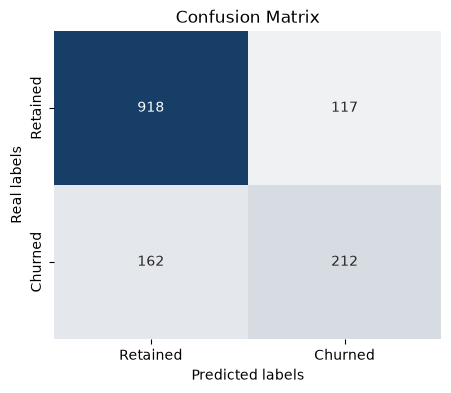

Test accuracy =  0.8019872249822569


0.8019872249822569

In [76]:
results["y_real"] = y_test
produce_confusion("Churned", "Retained", "binary", results, "y_pred", "y_real")

In [77]:
print(metrics.classification_report(y_test, results["y_pred"]))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



# 8. Finding the Best Threshold Value

In [78]:
for cut in [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
    pred = np.where(results["prob_churn"] > cut, 1, 0)
    print(f"{cut:.2f}  acc {metrics.accuracy_score(y_test, pred):.3f}"
          f"  recall {metrics.recall_score(y_test, pred):.3f}"
          f"  precision {metrics.precision_score(y_test, pred):.3f}"
          f"  f1 {metrics.f1_score(y_test, pred):.3f}")

0.20  acc 0.718  recall 0.858  precision 0.483  f1 0.618
0.25  acc 0.740  recall 0.786  precision 0.507  f1 0.616
0.30  acc 0.762  recall 0.746  precision 0.537  f1 0.624
0.35  acc 0.776  recall 0.717  precision 0.561  f1 0.629
0.40  acc 0.780  recall 0.663  precision 0.574  f1 0.615
0.45  acc 0.794  recall 0.615  precision 0.612  f1 0.613
0.50  acc 0.802  recall 0.567  precision 0.644  f1 0.603


# 9. Deliverable 1 — The 500 Customers Most Likely to Churn

In [79]:
scored = df_clean[["CustomerID", "Churn Value", "City", "Zip Code",
                   "Tenure Months", "Contract", "Internet Service",
                   "Payment Method", "Monthly Charges", "Total Charges"]
                  + ADDONS].copy()

scored[["prob_stay", "prob_churn"]] = model.predict_proba(X_enc)

retained = scored[scored["Churn Value"] == 0].drop(columns="Churn Value")
mailer_list = retained.sort_values("prob_churn", ascending=False).head(N_MAILERS)
mailer_list.head()

,CustomerID,City,Zip Code,Tenure Months,Contract,Internet Service,Payment Method,Monthly Charges,Total Charges,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,prob_stay,prob_churn
4624,3489-HHPFY,Amboy,92304,2,Month-to-month,Fiber optic,Electronic check,84.05,134.05,No,No,No,No,Yes,No,0.145981,0.854019
4198,5150-ITWWB,Hamilton City,95951,3,Month-to-month,Fiber optic,Electronic check,94.85,335.75,No,No,No,No,Yes,Yes,0.147506,0.852494
3732,4927-WWOOZ,Pacific Grove,93950,2,Month-to-month,Fiber optic,Electronic check,91.45,171.45,No,No,Yes,No,Yes,No,0.147761,0.852239
2567,6630-UJZMY,Palo Alto,94306,4,Month-to-month,Fiber optic,Electronic check,83.25,308.05,No,No,No,No,Yes,No,0.150869,0.849131
3141,7398-SKNQZ,Downey,90241,3,Month-to-month,Fiber optic,Electronic check,94.90,273.20,No,No,No,No,Yes,Yes,0.162631,0.837369


In [80]:
mailer_list.to_csv("mailer_list_500.csv", index=False)

In [81]:
mailer_list["expected_saved_revenue"] = (
    mailer_list["prob_churn"] * mailer_list["Monthly Charges"] * UPTAKE)

print("Monthly revenue on the list :", mailer_list["Monthly Charges"].sum().round(2))
print("Mean churn probability      :", mailer_list["prob_churn"].mean().round(4))
print("Expected churners           :", mailer_list["prob_churn"].sum().round(1))
print(f"Expected saves at {UPTAKE:.0%}       :", (mailer_list["prob_churn"].sum() * UPTAKE).round(1))
print("Monthly revenue protected   :", mailer_list["expected_saved_revenue"].sum().round(2))
print("Annualised                  :", (mailer_list["expected_saved_revenue"].sum() * 12).round(2))

Monthly revenue on the list : 40060.25
Mean churn probability      : 0.6433
Expected churners           : 321.6
Expected saves at 20%       : 64.3
Monthly revenue protected   : 5189.0
Annualised                  : 62268.05


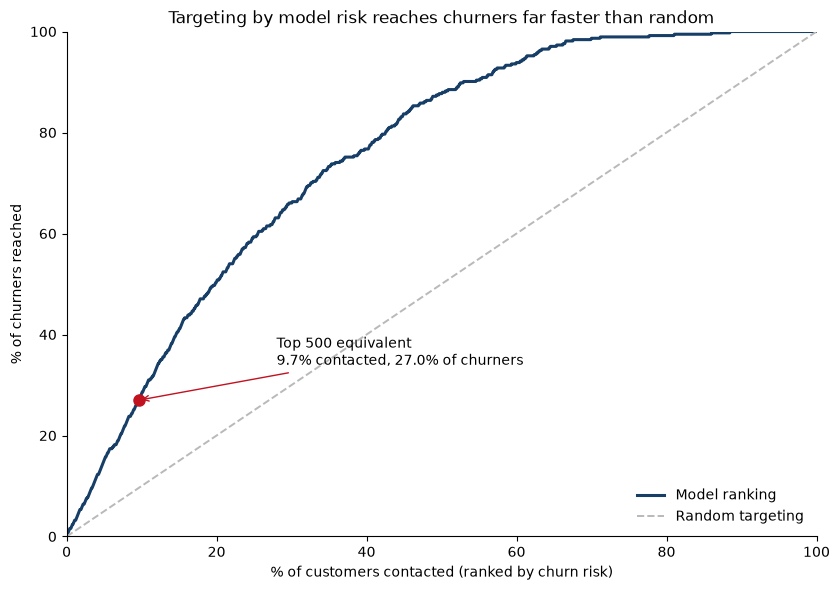

In [82]:
ranked = results.sort_values("prob_churn", ascending=False)
n = len(ranked)

pct_contacted = np.arange(1, n + 1) / n * 100
pct_captured = ranked["y_real"].cumsum().values / ranked["y_real"].sum() * 100

mark = int(round(N_MAILERS / len(retained) * n))

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.plot(pct_contacted, pct_captured, color=NAVY, linewidth=2.2, label="Model ranking")
ax.plot([0, 100], [0, 100], color="#B9B9B9", linestyle="--", linewidth=1.4, label="Random targeting")

ax.plot(pct_contacted[mark-1], pct_captured[mark-1], "o", color=RED, markersize=8, zorder=5)
ax.annotate(f"Top {N_MAILERS} equivalent\n{pct_contacted[mark-1]:.1f}% contacted, "
            f"{pct_captured[mark-1]:.1f}% of churners",
            xy=(pct_contacted[mark-1], pct_captured[mark-1]), xytext=(28, 34),
            fontsize=10, arrowprops=dict(arrowstyle="->", color=RED))

ax.set_xlabel("% of customers contacted (ranked by churn risk)")
ax.set_ylabel("% of churners reached")
ax.set_title("Targeting by model risk reaches churners far faster than random", fontsize=12.5)
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

# 10. Deliverable 2 — Churn Risk of Remaining Customers

In [83]:
risk_register = retained.copy()
risk_register["churn_risk_pct"] = (risk_register["prob_churn"] * 100).round(1)
risk_register["risk_band"] = pd.cut(
    risk_register["prob_churn"],
    bins=[0, .10, .25, .45, .65, 1.0],
    labels=["Very low", "Low", "Medium", "High", "Very high"])

risk_register = risk_register.sort_values("CustomerID")
risk_register.to_csv("churn_risk_register.csv", index=False)
risk_register.head()

,CustomerID,City,Zip Code,Tenure Months,Contract,Internet Service,Payment Method,Monthly Charges,Total Charges,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,prob_stay,prob_churn,churn_risk_pct,risk_band
3564,0002-ORFBO,Frazier Park,93225,9,One year,DSL,Mailed check,65.60,593.30,No,Yes,No,Yes,Yes,No,0.756137,0.243863,24.4,Low
4447,0003-MKNFE,Glendale,91206,9,Month-to-month,DSL,Mailed check,59.90,542.40,No,No,No,No,No,Yes,0.561530,0.438470,43.8,Medium
2764,0013-MHZWF,Midpines,95345,9,Month-to-month,DSL,Credit card (automatic),69.40,571.45,No,No,No,Yes,Yes,Yes,0.886812,0.113188,11.3,Low
3624,0013-SMEOE,Lompoc,93437,71,Two year,Fiber optic,Bank transfer (automatic),109.70,7904.25,Yes,Yes,Yes,Yes,Yes,Yes,0.957457,0.042543,4.3,Very low
3815,0014-BMAQU,Napa,94558,63,Two year,Fiber optic,Credit card (automatic),84.65,5377.80,Yes,No,No,Yes,No,No,0.952223,0.047777,4.8,Very low


In [84]:
band_summary = risk_register.groupby("risk_band", observed=True).agg(
    customers=("CustomerID", "size"),
    mean_risk=("churn_risk_pct", "mean"),
    monthly_revenue=("Monthly Charges", "sum"),
    mean_monthly_revenue=("Monthly Charges", "mean"),
)
band_summary["share"] = (band_summary["customers"] / len(risk_register) * 100).round(1)
band_summary = band_summary[["customers", "share", "mean_risk",
                             "mean_monthly_revenue", "monthly_revenue"]].round(1)
band_summary

,customers,share,mean_risk,mean_monthly_revenue,monthly_revenue
risk_band,,,,,
Very low,2722,52.6,3.4,55.1,149870.2
Low,1056,20.4,16.6,61.9,65387.6
Medium,732,14.1,33.8,67.0,49067.8
High,450,8.7,54.7,77.1,34707.0
Very high,214,4.1,72.4,83.9,17953.0


In [85]:
band_by_service = pd.crosstab(
    risk_register["risk_band"],
    risk_register["Internet Service"],
    normalize="index").mul(100).round(1)
band_by_service

Internet Service,DSL,Fiber optic,No
risk_band,,,
Very low,40.6,19.5,39.9
Low,37.2,36.9,25.9
Medium,46.9,45.6,7.5
High,25.3,74.7,0.0
Very high,3.3,96.7,0.0


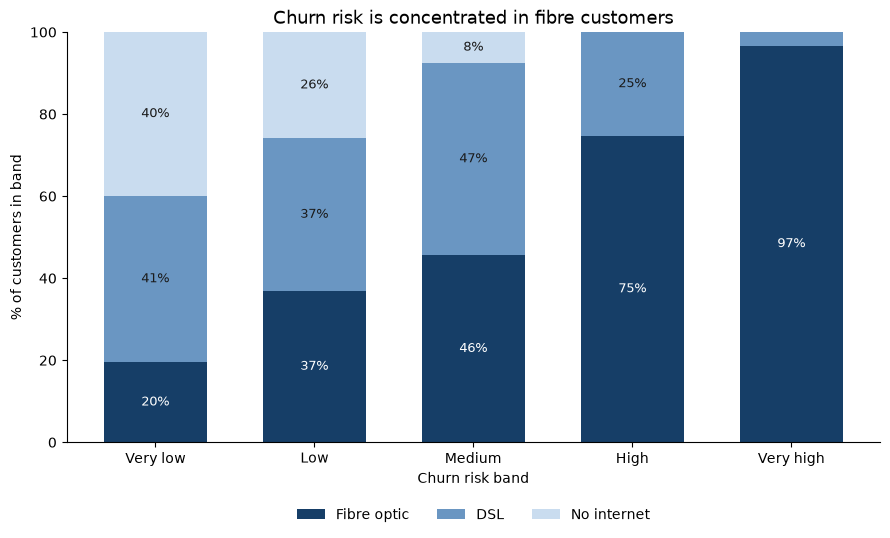

In [86]:
cols = ["Fiber optic", "DSL", "No"]
names = ["Fibre optic", "DSL", "No internet"]
shades = [NAVY, MID, PALE]

fig, ax = plt.subplots(figsize=(9, 5.5))
bottom = np.zeros(len(band_by_service))

for c, nm, sh in zip(cols, names, shades):
    vals = band_by_service[c].values
    bars = ax.bar(band_by_service.index.astype(str), vals, bottom=bottom,
                  label=nm, color=sh, width=.65)
    for b, v in zip(bars, vals):
        if v >= 6:
            ax.text(b.get_x() + b.get_width()/2, b.get_y() + v/2, f"{v:.0f}%",
                    ha="center", va="center", fontsize=9,
                    color="white" if sh == NAVY else "#1A1A1A")
    bottom += vals

ax.set_ylabel("% of customers in band")
ax.set_xlabel("Churn risk band")
ax.set_ylim(0, 100)
ax.set_title("Churn risk is concentrated in fibre customers", fontsize=13)
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(.5, -.13))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [87]:
very_high = set(risk_register.loc[risk_register.risk_band == "Very high", "CustomerID"])
in_mailer = set(mailer_list["CustomerID"])

print("Very high band          :", len(very_high))
print("  of those, in the 500  :", len(very_high & in_mailer))
print("High band               :", (risk_register.risk_band == "High").sum())
print("  in the 500            :", len(set(risk_register.loc[risk_register.risk_band == 'High', 'CustomerID']) & in_mailer))
print("  cut by the 500 budget :", (risk_register.risk_band == "High").sum()
      - len(set(risk_register.loc[risk_register.risk_band == 'High', 'CustomerID']) & in_mailer))

Very high band          : 214
  of those, in the 500  : 214
High band               : 450
  in the 500            : 286
  cut by the 500 budget : 164


# 11. What Factors Most Influence Someone Churning?

In [88]:
coefficients = pd.DataFrame({
    "feature": X_enc.columns,
    "coefficient": model.coef_[0],
    "odds_ratio": np.exp(model.coef_[0]),
}).sort_values("coefficient", ascending=False).reset_index(drop=True)

coefficients["pct_change"] = ((coefficients["odds_ratio"] - 1) * 100).round(1)
coefficients

,feature,coefficient,odds_ratio,pct_change
0,Internet Service_Fiber optic,0.980581,2.666004,166.6
1,Payment Method_Electronic check,0.374670,1.454512,45.5
2,Multiple Lines_Yes,0.368765,1.445948,44.6
3,Paperless Billing_Yes,0.356059,1.427692,42.8
4,Streaming TV_Yes,0.340537,1.405702,40.6
5,Streaming Movies_Yes,0.316839,1.372781,37.3
6,Partner_Yes,0.281334,1.324896,32.5
7,Payment Method_Mailed check,0.099710,1.104850,10.5
8,Senior Citizen_Yes,0.024522,1.024825,2.5
9,Gender_Male,0.016015,1.016144,1.6


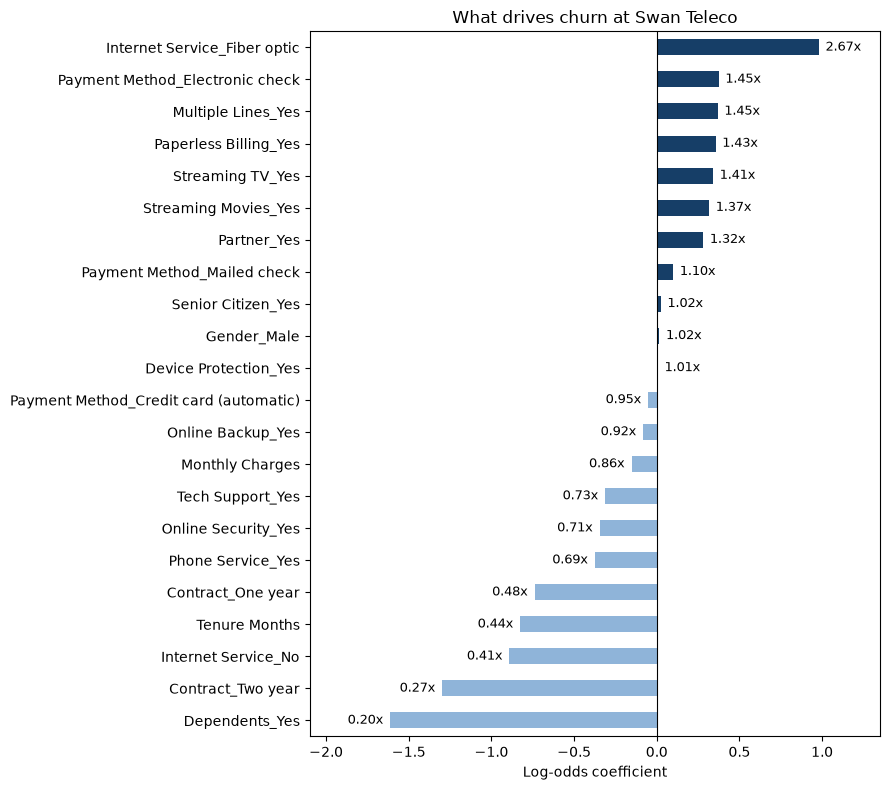

In [89]:
plot_df = coefficients.sort_values("coefficient")
colours = np.where(plot_df["coefficient"] > 0, NAVY, "#8FB4D9")

ax = plot_df.plot.barh(x="feature", y="coefficient", figsize=(9, 8),
                       legend=False, color=colours)
ax.axvline(0, color="black", linewidth=.8)

for bar, ratio in zip(ax.patches, plot_df["odds_ratio"]):
    w = bar.get_width()
    offset = 0.04 if w > 0 else -0.04
    ax.text(w + offset, bar.get_y() + bar.get_height()/2, f"{ratio:.2f}x",
            va="center", ha="left" if w > 0 else "right", fontsize=9)

ax.set_xlim(-2.1, 1.35)
ax.set_xlabel("Log-odds coefficient")
ax.set_ylabel("")
ax.set_title("What drives churn at Swan Teleco")
plt.tight_layout()
plt.show()

# 12. What Sign-Up Factor Should We Incentivise?

In [90]:
coefs = pd.Series(model.coef_[0], index=X_enc.columns)
retained_raw = df_clean[df_clean["Churn Value"] == 0]

incentive = pd.DataFrame({
    "odds_ratio": [np.exp(coefs[c + "_Yes"]) for c in ADDONS],
    "churn_with": [df_clean[df_clean[c] == "Yes"]["Churn Value"].mean() * 100 for c in ADDONS],
    "churn_without": [df_clean[df_clean[c] == "No"]["Churn Value"].mean() * 100 for c in ADDONS],
    "headroom": [((retained_raw[c] == "No") & (retained_raw["Internet Service"] != "No")).sum()
                 for c in ADDONS],
}, index=ADDONS)

incentive.sort_values("odds_ratio").round(2)

,odds_ratio,churn_with,churn_without,headroom
Online Security,0.71,14.61,31.33,2037
Tech Support,0.73,15.17,31.19,2027
Online Backup,0.92,21.53,29.17,1855
Device Protection,1.01,22.50,28.65,1884
Streaming Movies,1.37,29.94,24.38,1847
Streaming TV,1.41,30.07,24.33,1868


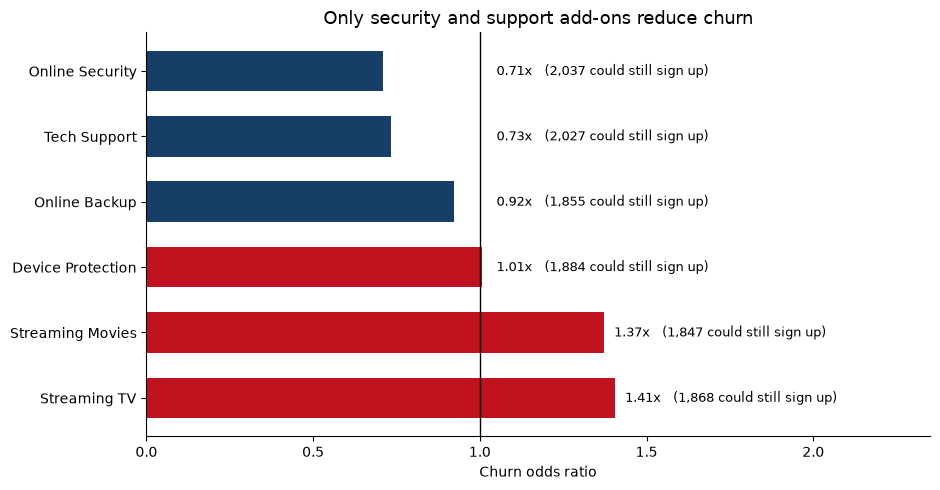

In [91]:
plot_inc = incentive.sort_values("odds_ratio", ascending=False)
colours = np.where(plot_inc["odds_ratio"] > 1, RED, NAVY)

fig, ax = plt.subplots(figsize=(9.5, 5))
bars = ax.barh(plot_inc.index, plot_inc["odds_ratio"], color=colours, height=.62, zorder=2)
ax.axvline(1, color="black", linewidth=1, zorder=3)

for b, orr, hd in zip(bars, plot_inc["odds_ratio"], plot_inc["headroom"]):
    x = max(orr + .03, 1.05)
    ax.text(x, b.get_y() + b.get_height()/2,
            f"{orr:.2f}x   ({hd:,} could still sign up)", va="center", fontsize=9, zorder=4)

ax.set_xlim(0, 2.35)
ax.set_xlabel("Churn odds ratio")
ax.set_title("Only security and support add-ons reduce churn", fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# 13. The Fibre Problem

In [92]:
churned = df_clean[df_clean["Churn Value"] == 1]

service_summary = df_clean.groupby("Internet Service").agg(
    customers=("CustomerID", "size"),
    churned=("Churn Value", "sum"),
    churn_rate=("Churn Value", "mean"),
)
service_summary["churn_rate"] = (service_summary["churn_rate"] * 100).round(1)
service_summary["share_of_base"] = (service_summary["customers"] / len(df_clean) * 100).round(1)

lost = churned.groupby("Internet Service")["Monthly Charges"].sum()
service_summary["monthly_lost"] = lost.round(2)
service_summary["share_of_lost"] = (lost / lost.sum() * 100).round(1)
service_summary["annualised_lost"] = (lost * 12).round(2)

service_summary

,customers,churned,churn_rate,share_of_base,monthly_lost,share_of_lost,annualised_lost
Internet Service,,,,,,,
DSL,2421,459,19.0,34.4,22529.20,16.2,270350.4
Fiber optic,3096,1297,41.9,44.0,114300.05,82.2,1371600.6
No,1526,113,7.4,21.7,2301.60,1.7,27619.2


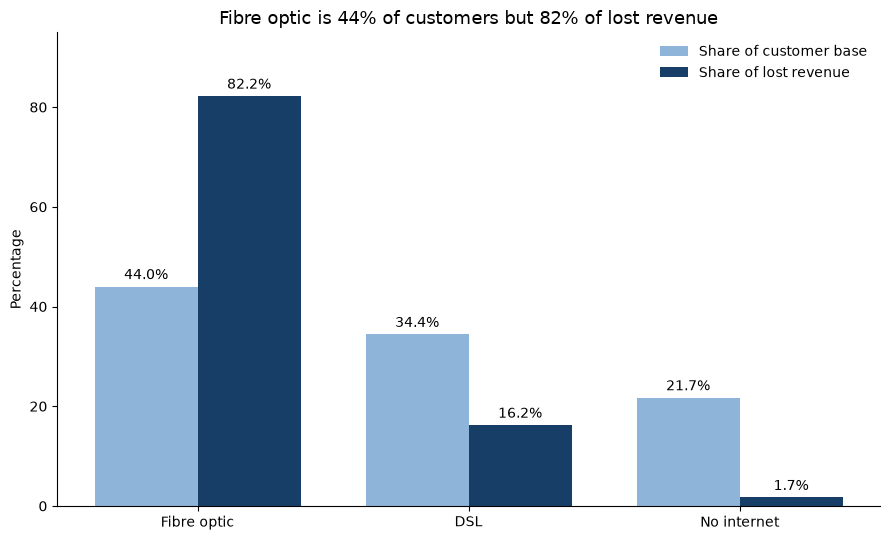

In [93]:
order = ["Fiber optic", "DSL", "No"]
labels = {"Fiber optic": "Fibre optic", "DSL": "DSL", "No": "No internet"}
plot = service_summary.loc[order]

worst = plot["share_of_lost"].idxmax()
title = (f"{labels[worst]} is {plot.loc[worst, 'share_of_base']:.0f}% of customers "
         f"but {plot.loc[worst, 'share_of_lost']:.0f}% of lost revenue")

x = np.arange(len(order))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5.5))
b1 = ax.bar(x - width/2, plot["share_of_base"], width,
            label="Share of customer base", color="#8FB4D9")
b2 = ax.bar(x + width/2, plot["share_of_lost"], width,
            label="Share of lost revenue", color=NAVY)

for bars in (b1, b2):
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10)

ax.set_xticks(x, [labels[o] for o in order])
ax.set_ylabel("Percentage")
ax.set_ylim(0, 95)
ax.set_title(title, fontsize=13)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [94]:
revenue_by_service = risk_register.pivot_table(
    index="risk_band",
    columns="Internet Service",
    values="Monthly Charges",
    aggfunc="mean",
    observed=True).round(1)
revenue_by_service

Internet Service,DSL,Fiber optic,No
risk_band,,,
Very low,65.9,101.3,21.3
Low,56.3,96.7,20.4
Medium,50.2,91.9,20.9
High,50.3,86.2,NaN
Very high,34.5,85.6,NaN


# 14. Demographics of Churners

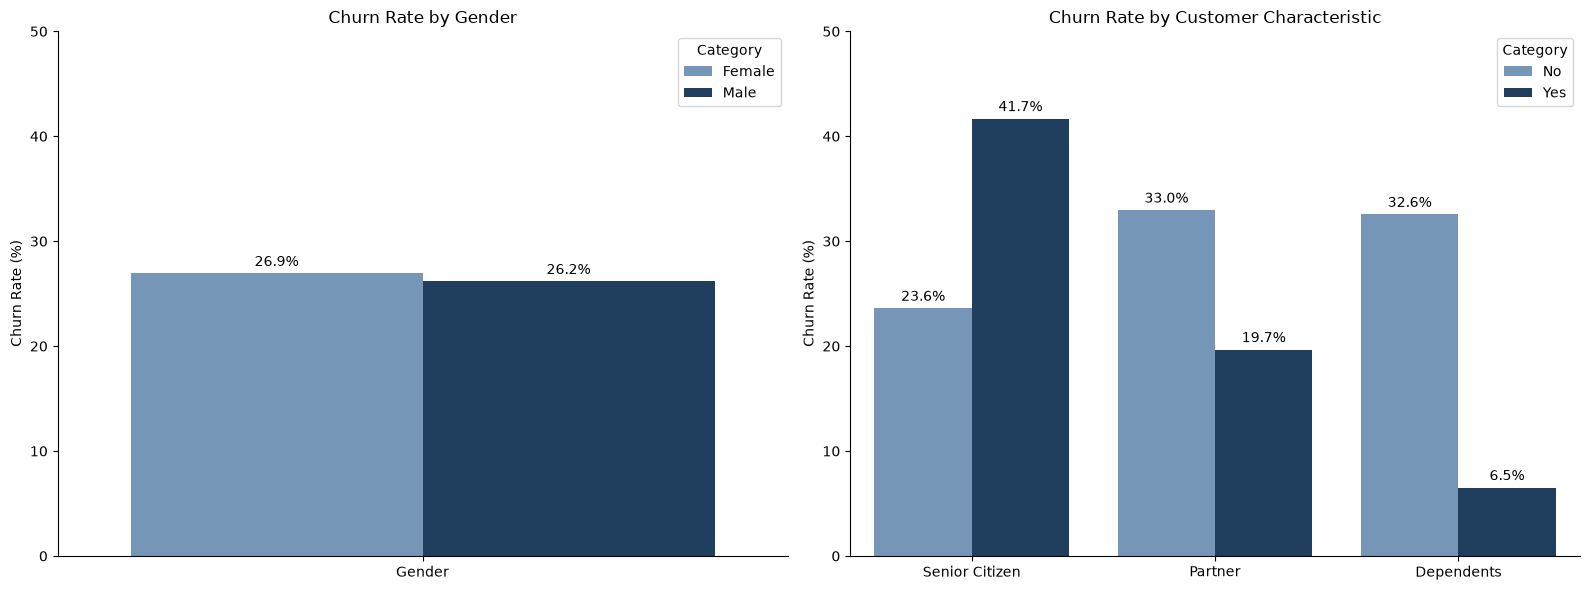

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rows = []
for col in ["Gender", "Senior Citizen", "Partner", "Dependents"]:
    rates = df_clean.groupby(col)["Churn Value"].mean().mul(100)
    for category, rate in rates.items():
        rows.append({"Variable": col, "Category": category, "Churn Rate": rate})
churn_df = pd.DataFrame(rows)

gender_df = churn_df[churn_df["Variable"] == "Gender"]
ax = sns.barplot(data=gender_df, x="Variable", y="Churn Rate", hue="Category",
                 ax=axes[0], palette=BINARY)
axes[0].set_title("Churn Rate by Gender")
axes[0].set_xlabel("")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 50)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

other_df = churn_df[churn_df["Variable"] != "Gender"]
ax2 = sns.barplot(data=other_df, x="Variable", y="Churn Rate", hue="Category",
                  ax=axes[1], palette=BINARY)
axes[1].set_title("Churn Rate by Customer Characteristic")
axes[1].set_xlabel("")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_ylim(0, 50)
for container in ax2.containers:
    ax2.bar_label(container, fmt="%.1f%%", padding=3)

for a in axes:
    a.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

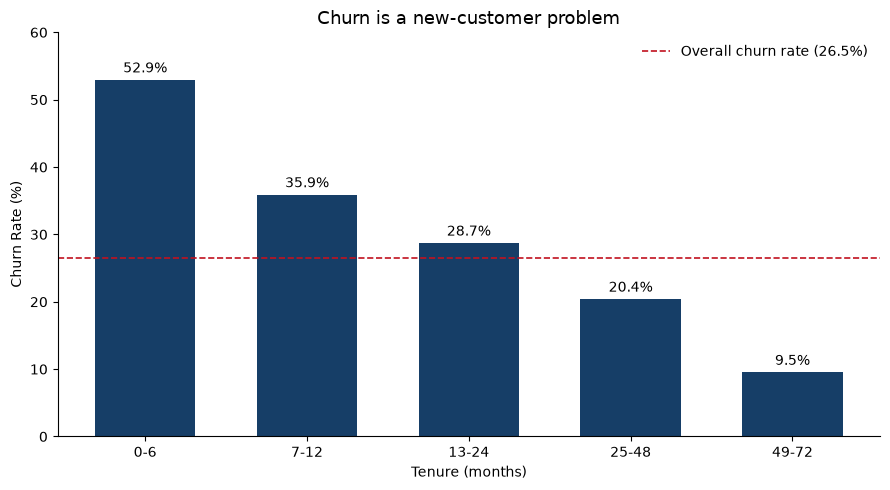

In [96]:
df_clean["tenure_band"] = pd.cut(df_clean["Tenure Months"], [-1, 6, 12, 24, 48, 72],
                                 labels=["0-6", "7-12", "13-24", "25-48", "49-72"])

tenure_rates = df_clean.groupby("tenure_band", observed=True)["Churn Value"].mean().mul(100)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(tenure_rates.index.astype(str), tenure_rates.values, color=NAVY, width=.62)
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.axhline(df_clean["Churn Value"].mean() * 100, color=RED, linestyle="--", linewidth=1.2,
           label=f"Overall churn rate ({df_clean['Churn Value'].mean()*100:.1f}%)")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 60)
ax.set_title("Churn is a new-customer problem", fontsize=13)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

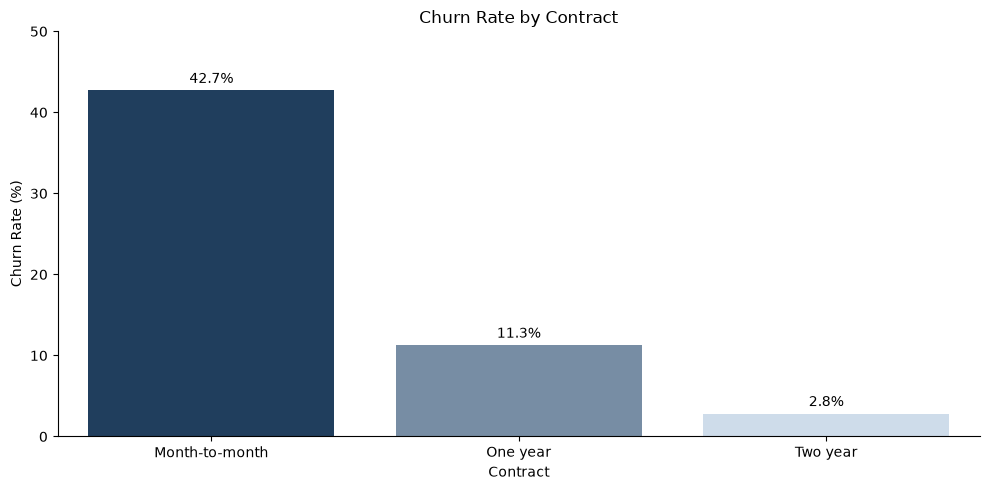

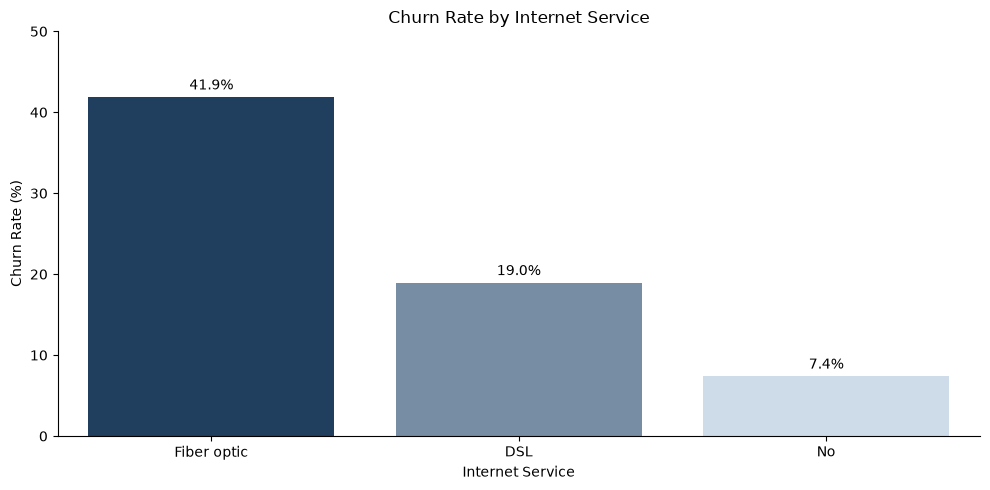

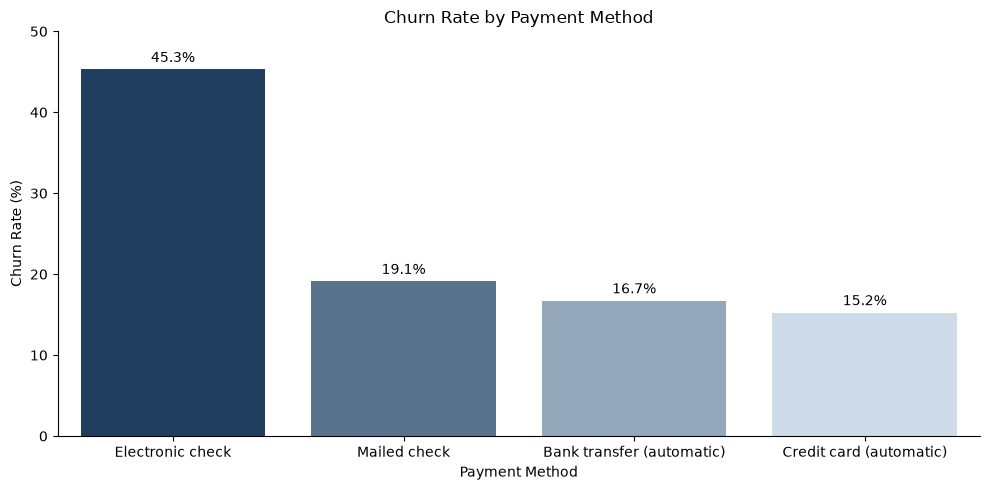

In [97]:
for col in ["Contract", "Internet Service", "Payment Method"]:
    churn_rates = df_clean.groupby(col)["Churn Value"].mean().mul(100).sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=churn_rates.index, y=churn_rates.values,
                     hue=churn_rates.index, palette=blue_ramp(len(churn_rates)), legend=False)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)

    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate (%)")
    plt.ylim(0, 50)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

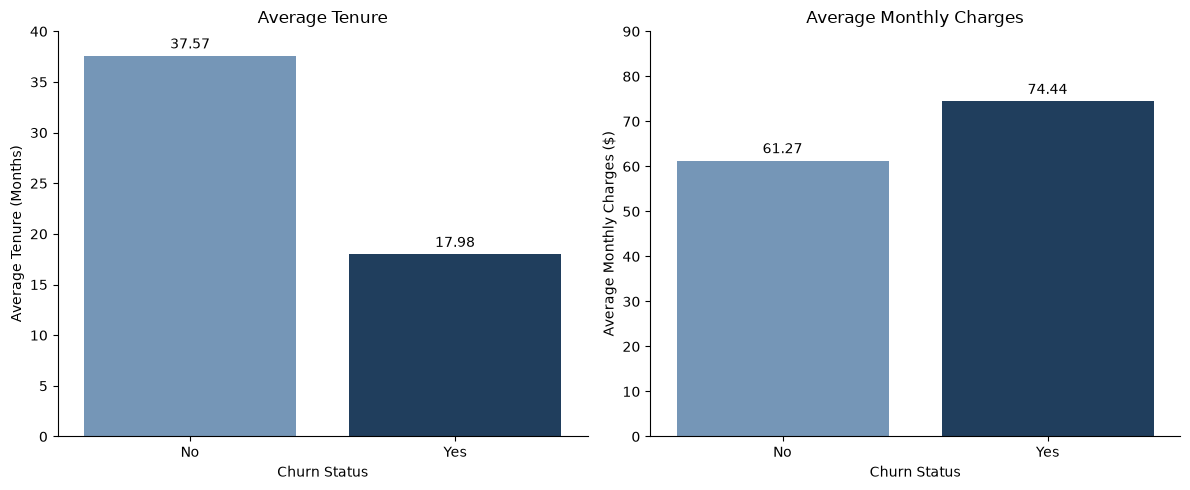

In [98]:
churn_summary = df_clean.groupby("Churn Label")[["Tenure Months", "Monthly Charges"]].mean().round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=churn_summary.index, y=churn_summary["Tenure Months"], ax=axes[0],
            hue=churn_summary.index, palette=BINARY, legend=False)
axes[0].set_title("Average Tenure")
axes[0].set_xlabel("Churn Status")
axes[0].set_ylabel("Average Tenure (Months)")
axes[0].set_ylim(0, 40)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", padding=3)

sns.barplot(x=churn_summary.index, y=churn_summary["Monthly Charges"], ax=axes[1],
            hue=churn_summary.index, palette=BINARY, legend=False)
axes[1].set_title("Average Monthly Charges")
axes[1].set_xlabel("Churn Status")
axes[1].set_ylabel("Average Monthly Charges ($)")
axes[1].set_ylim(0, 90)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=3)

for a in axes:
    a.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# 15. Why They Leave

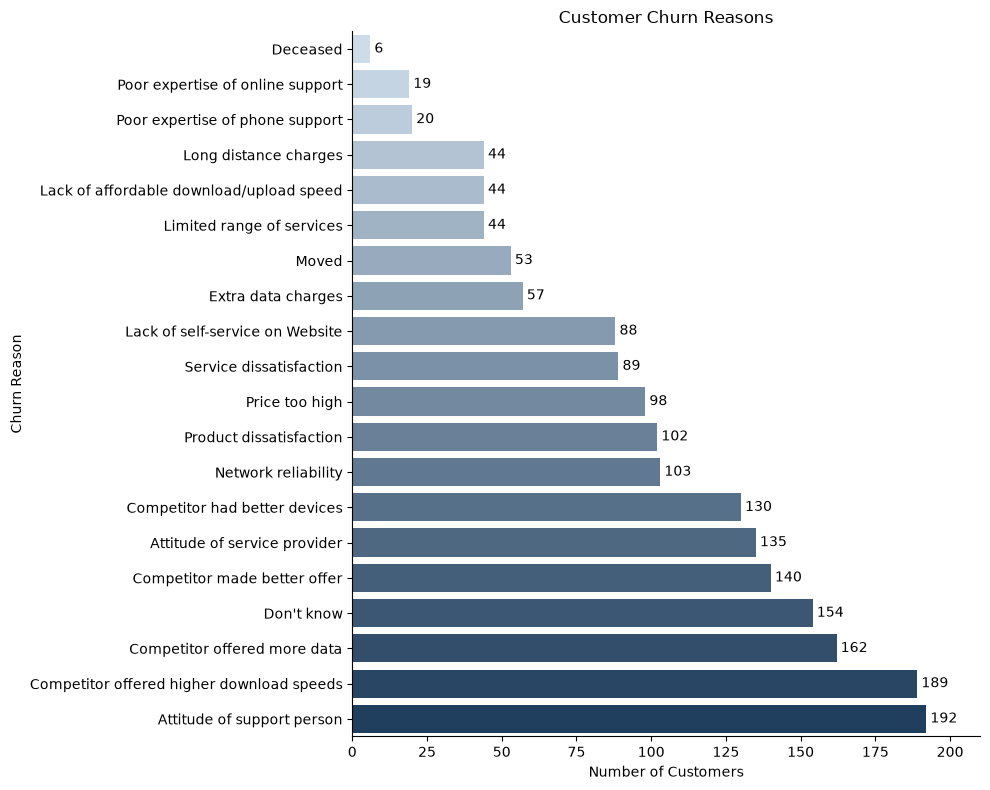

In [99]:
churn_reasons = df_clean["Churn Reason"].dropna().value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=churn_reasons.values, y=churn_reasons.index, hue=churn_reasons.index,
                 palette=blue_ramp(len(churn_reasons), reverse=True), legend=False)
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Customer Churn Reasons")
plt.xlabel("Number of Customers")
plt.xlim(0, 210)
plt.ylabel("Churn Reason")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

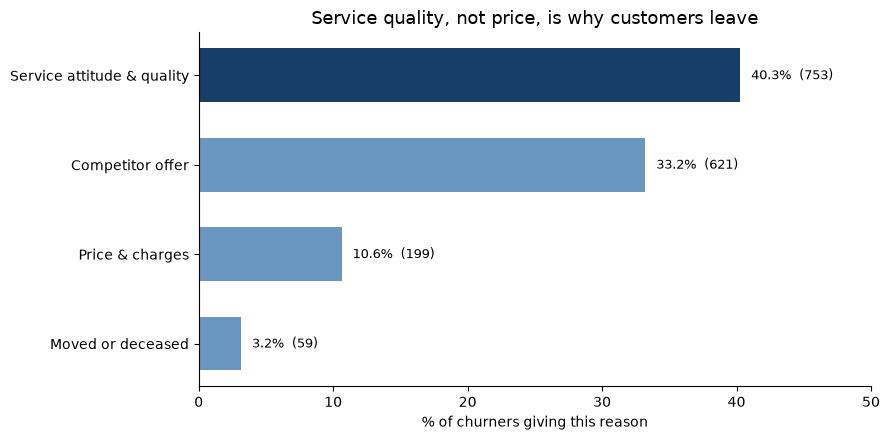

Moved or deceased              59
Price & charges               199
Competitor offer              621
Service attitude & quality    753
dtype: int64

In [100]:
reasons = df_clean["Churn Reason"].dropna()

themes = {
    "Service attitude & quality": reasons.str.contains("Attitude|dissatisfaction|reliability|Service",
                                                       case=False).sum(),
    "Competitor offer": reasons.str.contains("Competitor").sum(),
    "Price & charges": reasons.str.contains("Price|charges|Extra|Long distance", case=False).sum(),
    "Moved or deceased": reasons.str.contains("Moved|Deceased").sum(),
}
theme_s = pd.Series(themes).sort_values()
theme_pct = theme_s / len(reasons) * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(theme_s.index, theme_pct.values,
               color=[NAVY if v == theme_pct.max() else MID for v in theme_pct.values], height=.6)
for b, v, n in zip(bars, theme_pct.values, theme_s.values):
    ax.text(v + .8, b.get_y() + b.get_height()/2, f"{v:.1f}%  ({n})", va="center", fontsize=9)

ax.set_xlim(0, 50)
ax.set_xlabel("% of churners giving this reason")
ax.set_title("Service quality, not price, is why customers leave", fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

theme_s

# 16. Add-On Economics

In [101]:
addon_economics = pd.DataFrame(index=ADDONS)

addon_economics["total_users"] = [(df_clean[a] == "Yes").sum() for a in ADDONS]
addon_economics["churned_users"] = [(churned[a] == "Yes").sum() for a in ADDONS]
addon_economics["churn_rate"] = (addon_economics["churned_users"]
                                 / addon_economics["total_users"] * 100).round(1)
addon_economics["monthly_rev_lost"] = [churned[churned[a] == "Yes"]["Monthly Charges"].sum()
                                       for a in ADDONS]
addon_economics["total_rev_lost"] = [churned[churned[a] == "Yes"]["Total Charges"].sum()
                                     for a in ADDONS]
addon_economics["monthly_rev_kept"] = [retained_raw[retained_raw[a] == "Yes"]["Monthly Charges"].sum()
                                       for a in ADDONS]
addon_economics["mean_monthly_charge"] = [df_clean[df_clean[a] == "Yes"]["Monthly Charges"].mean()
                                          for a in ADDONS]
addon_economics["mean_risk_top500"] = [
    retained[retained[a] == "Yes"].sort_values("prob_churn", ascending=False)
            .head(N_MAILERS)["prob_churn"].mean()
    for a in ADDONS]

addon_economics.round(2).sort_values("churn_rate")

,total_users,churned_users,churn_rate,monthly_rev_lost,total_rev_lost,monthly_rev_kept,mean_monthly_charge,mean_risk_top500
Online Security,2019,295,14.6,24066.50,764668.80,135108.90,78.84,0.29
Tech Support,2044,310,15.2,26119.45,819494.60,138790.75,80.68,0.31
Online Backup,2429,523,21.5,44955.40,1436303.00,156849.80,83.08,0.41
Device Protection,2422,545,22.5,48077.00,1459204.15,157362.50,84.82,0.41
Streaming Movies,2732,818,29.9,73565.70,2004345.35,168149.95,88.48,0.52
Streaming TV,2707,814,30.1,73664.85,1998686.10,166545.50,88.74,0.52


In [102]:
price_cols = ["Phone Service", "Multiple Lines"] + ADDONS

P = pd.DataFrame({c: (df_clean[c] == "Yes").astype(int) for c in price_cols})
P["DSL"] = (df_clean["Internet Service"] == "DSL").astype(int)
P["Fibre"] = (df_clean["Internet Service"] == "Fiber optic").astype(int)

lm = LinearRegression().fit(P, df_clean["Monthly Charges"])

prices = pd.Series(lm.coef_, index=P.columns).sort_values(ascending=False)
print("R-squared :", round(lm.score(P, df_clean["Monthly Charges"]), 4))
print("Intercept : $%.2f" % lm.intercept_)
prices.map("${:,.2f}".format)

R-squared : 0.9988
Intercept : $-0.10


Fibre                $50.01
DSL                  $25.05
Phone Service        $20.05
Streaming TV          $9.97
Streaming Movies      $9.96
Tech Support          $5.03
Device Protection     $5.02
Online Security       $5.01
Multiple Lines        $5.01
Online Backup         $4.99
dtype: str

# 17. Appendix — Gradient Boosted Trees Cross-Check

In [103]:
try:
    import ydf
    YDF_AVAILABLE = True
except ImportError:
    YDF_AVAILABLE = False
    print("ydf not installed - skipping. Run: pip install ydf")

Train model on 5634 examples
Model trained in 0:00:00.205911
YDF AUC: 0.8521


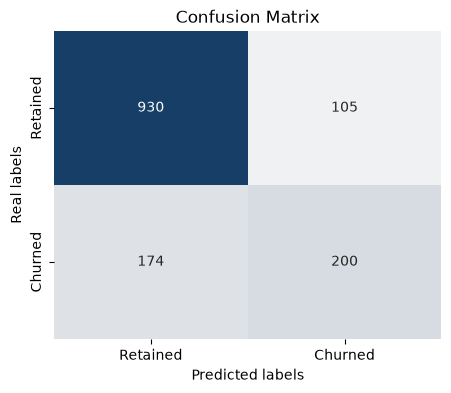

Test accuracy =  0.8019872249822569


In [104]:
if YDF_AVAILABLE:
    df_ydf = df_clean.drop(columns=["CustomerID", "Count", "Country", "State", "City",
                                    "Lat Long", "Churn Reason", "Churn Label",
                                    "tenure_band"], errors="ignore").copy()

    yes_no = [c for c in df_ydf.columns
              if set(df_ydf[c].dropna().unique()) <= {"Yes", "No"}]
    for c in yes_no:
        df_ydf[c] = df_ydf[c].map({"Yes": 1, "No": 0})
    df_ydf["Gender"] = df_ydf["Gender"].map({"Male": 0, "Female": 1})

    df_ydf = pd.get_dummies(df_ydf, columns=["Internet Service", "Contract", "Payment Method"],
                            prefix=["IS", "Cnt", "PM"], dtype=int, drop_first=True)

    service_list = ["Phone Service", "Multiple Lines"] + ADDONS
    df_ydf["Service Count"] = (df_ydf[service_list] == 1).sum(axis=1)

    ydf_train, ydf_test = train_test_split(
        df_ydf, test_size=.2, random_state=42, stratify=df_ydf["Churn Value"])

    ydf_model = ydf.GradientBoostedTreesLearner(label="Churn Value").train(ydf_train)

    ydf_results = ydf_test.copy()
    ydf_results["prob_churn"] = ydf_model.predict(ydf_test)
    ydf_results["y_real"] = ydf_test["Churn Value"]

    print("YDF AUC:", round(roc_auc_score(ydf_results["y_real"], ydf_results["prob_churn"]), 4))
    produce_confusion("Churned", "Retained", 0.5, ydf_results, "prob_churn", "y_real")

In [105]:
if YDF_AVAILABLE:
    display(ydf_model.variable_importances())

{'SUM_SCORE': [(602.3803704498823, 'Tenure Months'),
  (399.70658962454763, 'IS_Fiber optic'),
  (260.98290135757634, 'PM_Electronic check'),
  (195.8175246329247, 'Dependents'),
  (145.0562650215693, 'Total Charges'),
  (126.08927668107208, 'Monthly Charges'),
  (106.04183116790227, 'Zip Code'),
  (87.17958442562667, 'Cnt_Two year'),
  (80.89073649072816, 'Cnt_One year'),
  (77.9028660213371, 'Latitude'),
  (60.16693201448288, 'Longitude'),
  (43.891051663667895, 'IS_No'),
  (28.7805355679302, 'Paperless Billing'),
  (27.297606842184905, 'Tech Support'),
  (25.623590144168702, 'Online Security'),
  (25.007031320012175, 'Multiple Lines'),
  (22.81721168162767, 'Streaming Movies'),
  (15.746581939522002, 'Partner'),
  (13.391414323094068, 'Streaming TV'),
  (12.353559274808504, 'Phone Service'),
  (11.667779961804627, 'Senior Citizen'),
  (8.320452128595207, 'Service Count'),
  (7.4015357932657935, 'Gender'),
  (6.021718688309193, 'Online Backup'),
  (2.4869799873558804, 'PM_Mailed chec